# Random50 Initial Features: MLOps Research Notebook

Notebook này dùng để kiểm tra và chạy pipeline `research_random50_initial_features.py` theo dạng MLOps checklist.

Các pha: environment -> data/cache contract -> feature profiling -> optional cache rebuild -> smoke/research run -> result audit -> MLflow/artifact audit.

Các cell chạy training mặc định tắt để tránh chạy ngoài ý muốn.

In [1]:
from __future__ import annotations

import json
import os
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Image

PROJECT = Path(r"D:\SCJ999\srateries\RandomForest\RF_MLFlow")
SCRIPT = PROJECT / "research_random50_initial_features.py"
CACHE_FAMILY = "initial_non_bb_candidates"

os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "axes.titleweight": "bold"})

print({"project": str(PROJECT), "python": sys.version.split()[0], "platform": platform.platform()})
assert SCRIPT.exists(), SCRIPT

{'project': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow', 'python': '3.11.9', 'platform': 'Windows-10-10.0.26200-SP0'}


## 1. Experiment parameters

`research_random50_initial_features.py` dùng LightGBM, random feature sets, time/session fixed features, scaler `RobustClipScalerLite`, cache `initial_non_bb_candidates`.

In [3]:
RUN_REBUILD_CACHE = False
RUN_SMOKE = False
RUN_RESEARCH = False

SEED = 51050

research_config = dict(
    force_cache=False,
    n_models=50,
    max_train_rows=120000,
    shap_rows=0,
    pairplot_top=5,
    seed=SEED,
    start_index=1,
)

research_config

{'force_cache': False,
 'n_models': 50,
 'max_train_rows': 120000,
 'shap_rows': 0,
 'pairplot_top': 5,
 'seed': 51050,
 'start_index': 1}

## 2. Environment and pipeline imports

In [4]:
import lightgbm as lgb
import sklearn
import pyarrow

from config import CFG
from research_random50_initial_features import (
    CACHE_FAMILY as PIPELINE_CACHE_FAMILY,
    FEATURE_FAMILY,
    META_COLS,
    TIME_FIXED_FEATURES,
    _cache_dir,
    _feature_groups,
    _mlflow,
    _random_feature_sets,
    _year_path,
    build_cache,
    run as run_random50,
)

versions = {
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "sklearn": sklearn.__version__,
    "lightgbm": lgb.__version__,
    "pyarrow": pyarrow.__version__,
}

contract = {
    "feature_family": FEATURE_FAMILY,
    "cache_family": PIPELINE_CACHE_FAMILY,
    "model_type": "LightGBM",
    "time_fixed_features": TIME_FIXED_FEATURES,
    "train_years": list(CFG.split.train_years),
    "valid_years": list(CFG.split.valid_years),
    "test_years": list(CFG.split.test_years),
    "experiment_name": CFG.experiment_name,
}

display(pd.Series(versions, name="version"))
display(pd.Series(contract, name="contract"))

python     3.11.9
pandas      2.3.1
numpy      1.26.4
sklearn     1.5.2
pyarrow    25.0.1
Name: version, dtype: object

feature_family       random50_initial_features_tod_dow_baseline
cache_family                          initial_non_bb_candidates
baseline_features          [tod_sin, tod_cos, dow_sin, dow_cos]
train_years                      [2018, 2019, 2020, 2021, 2022]
valid_years                                              [2023]
test_years                                   [2024, 2025, 2026]
experiment_name                 RF_MLFlow_XAUUSD_M1_Buy_WinLose
Name: contract, dtype: object

## 3. Cache contract

Kiểm tra cache manifest, feature count, overlay count và một parquet sample.

In [5]:
cache_dir = _cache_dir()
cols_path = cache_dir / "feature_columns.json"

if not cols_path.exists():
    print("feature_columns.json missing. Set RUN_REBUILD_CACHE=True and run rebuild cell.")
else:
    cols = json.loads(cols_path.read_text(encoding="utf-8"))
    cache_summary = {
        "cache_dir": str(cache_dir),
        "feature_columns": len(cols),
        "duplicate_features": int(pd.Series(cols).duplicated().sum()),
        "overlay_features": sum("_ov_" in c for c in cols),
        "time_features": sum(c.startswith(("tod_", "dow_", "session_")) for c in cols),
        "signal_features": sum(c.startswith("sig_") or c == "buy_signal" for c in cols),
    }
    display(pd.Series(cache_summary, name="cache_summary"))

cache_dir             D:\SCJ999\srateries\RandomForest\RF_MLFlow\cac...
feature_columns                                                    1404
duplicate_features                                                    0
overlay_features                                                   1224
time_features                                                         7
signal_features                                                       4
Name: cache_summary, dtype: object

In [6]:
sample_year = CFG.split.train_years[0]
sample_path = _year_path(sample_year)
assert sample_path.exists(), sample_path

sample = pd.read_parquet(sample_path)
sample_features = [c for c in sample.columns if c not in META_COLS and c != "label"]
numeric = sample.select_dtypes(include=np.number)

data_quality = pd.DataFrame(
    {
        "metric": ["year", "rows", "columns", "features", "missing_cells", "infinite_cells", "label_rate"],
        "value": [
            sample_year,
            len(sample),
            len(sample.columns),
            len(sample_features),
            int(sample.isna().sum().sum()),
            int(np.isinf(numeric.to_numpy(dtype="float64", copy=False)).sum()),
            float(sample["label"].mean()) if "label" in sample else np.nan,
        ],
    }
)
display(data_quality)

,metric,value
0,year,2018.000000
1,rows,112082.000000
2,columns,1410.000000
3,features,1404.000000
4,missing_cells,0.000000
5,infinite_cells,0.000000
6,label_rate,0.472172


## 4. Feature family profiling

,group,n_features
10,ma_overlay,408
11,bb_overlay,306
12,channel_overlay,306
14,trendline_overlay,204
3,rolling,48
2,lags,32
4,ema,19
6,mtf_m5,15
7,mtf_m15,15
8,mtf_h1,15


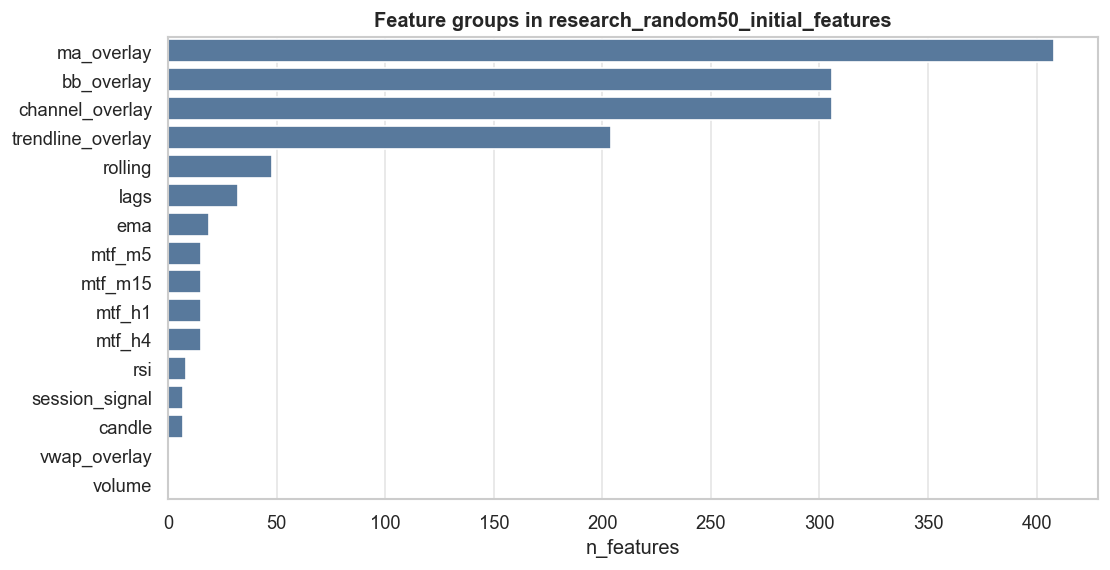

In [7]:
cols = json.loads(cols_path.read_text(encoding="utf-8"))
groups = _feature_groups(cols)
group_count = pd.DataFrame([{"group": k, "n_features": len(v)} for k, v in groups.items()]).sort_values("n_features", ascending=False)
display(group_count)

plt.figure(figsize=(10, 5))
sns.barplot(data=group_count, x="n_features", y="group", color="#4c78a8")
plt.title("Feature groups in research_random50_initial_features")
plt.xlabel("n_features")
plt.ylabel("")
plt.show()

In [11]:
feature_df = pd.DataFrame({"feature": cols})
feature_df["family"] = np.select(
    [
        feature_df.feature.str.contains("_ov_", regex=False),
        feature_df.feature.str.startswith("h4_"),
        feature_df.feature.str.startswith("h1_"),
        feature_df.feature.str.startswith("m15_"),
        feature_df.feature.str.startswith("m5_"),
        feature_df.feature.str.startswith(("tod_", "dow_", "session_")),
        feature_df.feature.str.startswith("sig_") | (feature_df.feature == "buy_signal"),
    ],
    ["overlay", "h4", "h1", "m15", "m5", "time_session", "signal"],
    default="other",
)
display(feature_df.groupby("family").size().sort_values(ascending=False).to_frame("n_features"))

,n_features
family,
overlay,1224
other,109
h1,15
h4,15
m15,15
m5,15
time_session,7
signal,4


## 5. Random model specs preview

Cell này chỉ preview specs, chưa train.

In [12]:
specs = _random_feature_sets(cols, n_models=50, seed=SEED)
spec_rows = []
for spec in specs:
    fs = spec["features"]
    spec_rows.append(
        {
            "model_name": spec["model_name"],
            "n_features": len(fs),
            "groups": "|".join(spec["groups"]),
            "overlay_features": sum("_ov_" in c for c in fs),
            "time_features": sum(c.startswith(("tod_", "dow_", "session_")) for c in fs),
            "signal_features": sum(c.startswith("sig_") or c == "buy_signal" for c in fs),
        }
    )
spec_df = pd.DataFrame(spec_rows)
display(spec_df.sort_values("n_features", ascending=False).head(15))
display(spec_df.describe(include="all"))

,model_name,n_features,groups,overlay_features,time_features,signal_features
5,rf_random_06,64,ma_overlay|channel_overlay|rsi|lags|trendline_...,25,4,0
33,rf_random_34,60,mtf_h4|mtf_m5|rsi|ema|trendline_overlay|sessio...,10,6,4
17,rf_random_18,59,mtf_m5|mtf_h1|trendline_overlay|ma_overlay|mtf...,13,5,3
24,rf_random_25,54,mtf_h4|trendline_overlay|mtf_m5|candle|ma_over...,17,4,0
44,rf_random_45,53,ma_overlay|trendline_overlay|ema|mtf_m5|sessio...,21,7,4
18,rf_random_19,53,trendline_overlay|session_signal|ema|bb_overla...,17,4,3
37,rf_random_38,52,mtf_h4|candle|rolling|ema|bb_overlay|mtf_m5,6,4,0
12,rf_random_13,51,candle|rsi|trendline_overlay|rolling|mtf_m15|m...,10,4,0
35,rf_random_36,51,mtf_h1|candle|lags|mtf_m15|mtf_h4|ema,0,4,0
46,rf_random_47,49,rolling|ma_overlay|trendline_overlay|ema|rsi|m...,12,4,0


,model_name,n_features,groups,overlay_features,time_features,signal_features
count,50,50.000000,50,50.000000,50.000000,50.000000
unique,50,NaN,50,NaN,NaN,NaN
top,rf_random_01,NaN,candle|rsi|lags,NaN,NaN,NaN
freq,1,NaN,1,NaN,NaN,NaN
mean,NaN,35.800000,NaN,7.200000,4.440000,0.720000
std,NaN,12.470373,NaN,6.366366,0.860944,1.309931
min,NaN,13.000000,NaN,0.000000,4.000000,0.000000
25%,NaN,27.250000,NaN,2.250000,4.000000,0.000000
50%,NaN,32.000000,NaN,6.000000,4.000000,0.000000
75%,NaN,47.500000,NaN,12.000000,4.750000,1.000000


## 6. Optional cache rebuild

Chỉ bật nếu cần rebuild cache từ raw data. Có thể tốn RAM/thời gian vì cache hiện có nhiều overlay features.

In [ ]:
if RUN_REBUILD_CACHE:
    rebuilt_cols = build_cache(True)
    print({"rebuilt_features": len(rebuilt_cols)})

## 7. Smoke run

Chạy rất nhỏ để kiểm tra control flow. Không dùng để kết luận model.

In [13]:
smoke_config = {**research_config, "force_cache": False, "n_models": 2, "max_train_rows": 3000, "shap_rows": 0, "pairplot_top": 0}
smoke_config

{'force_cache': False,
 'n_models': 2,
 'max_train_rows': 3000,
 'shap_rows': 0,
 'pairplot_top': 0,
 'seed': 51050,
 'start_index': 1}

In [14]:
if RUN_SMOKE:
    smoke_summary = run_random50(**smoke_config)
    display(pd.Series(smoke_summary, name="smoke_summary"))

## 8. Research run

Bật `RUN_RESEARCH=True` nếu muốn chạy nghiên cứu. Với cache overlay lớn, nên bắt đầu với `max_train_rows=60000`, `shap_rows=0`.

{'phase': 'cache_exists', 'year': 2018, 'path': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\cache\\initial_non_bb_candidates\\candidates_2018.parquet'}
{'phase': 'cache_exists', 'year': 2019, 'path': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\cache\\initial_non_bb_candidates\\candidates_2019.parquet'}
{'phase': 'cache_exists', 'year': 2020, 'path': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\cache\\initial_non_bb_candidates\\candidates_2020.parquet'}
{'phase': 'cache_exists', 'year': 2021, 'path': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\cache\\initial_non_bb_candidates\\candidates_2021.parquet'}
{'phase': 'cache_exists', 'year': 2022, 'path': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\cache\\initial_non_bb_candidates\\candidates_2022.parquet'}
{'phase': 'cache_exists', 'year': 2023, 'path': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\cache\\initial_non_bb_candidates\\candidates_2023.parquet'}
{'phase': 'cache_exists', 'year': 2024, 'path': 'D:\\SCJ99

D:\SCJ999\srateries\RandomForest\RF_MLFlow\research_random50_initial_features.py:582: RuntimeWarning: Mean of empty slice.
  values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1072: RuntimeWarning: Mean of empty slice.
  global_shap_values = np.abs(shap_values).mean(0)
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


{'phase': 'mlflow_log', 'name': 'rf_random_01'}
{'phase': 'model', 'idx': 2, 'n_models': 50, 'name': 'rf_random_02', 'features': 44}
{'phase': 'load_data', 'name': 'rf_random_02'}
{'phase': 'scale_train', 'name': 'rf_random_02'}
{'phase': 'fit_rf', 'name': 'rf_random_02', 'params': {'n_estimators': 60, 'max_depth': 8, 'min_samples_leaf': 350, 'min_samples_split': 1600, 'max_features': 'sqrt', 'max_samples': 0.65, 'class_weight': None}}
{'phase': 'predict_eval', 'name': 'rf_random_02'}
{'phase': 'shap', 'name': 'rf_random_02', 'rows': 0}
{'phase': 'mlflow_log', 'name': 'rf_random_02'}


D:\SCJ999\srateries\RandomForest\RF_MLFlow\research_random50_initial_features.py:582: RuntimeWarning: Mean of empty slice.
  values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1072: RuntimeWarning: Mean of empty slice.
  global_shap_values = np.abs(shap_values).mean(0)
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


{'phase': 'model', 'idx': 3, 'n_models': 50, 'name': 'rf_random_03', 'features': 31}
{'phase': 'load_data', 'name': 'rf_random_03'}
{'phase': 'scale_train', 'name': 'rf_random_03'}
{'phase': 'fit_rf', 'name': 'rf_random_03', 'params': {'n_estimators': 70, 'max_depth': 8, 'min_samples_leaf': 500, 'min_samples_split': 900, 'max_features': 'sqrt', 'max_samples': 0.75, 'class_weight': None}}
{'phase': 'predict_eval', 'name': 'rf_random_03'}
{'phase': 'shap', 'name': 'rf_random_03', 'rows': 0}
{'phase': 'mlflow_log', 'name': 'rf_random_03'}


...

D:\SCJ999\srateries\RandomForest\RF_MLFlow\research_random50_initial_features.py:582: RuntimeWarning: Mean of empty slice.
  values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1072: RuntimeWarning: Mean of empty slice.
  global_shap_values = np.abs(shap_values).mean(0)
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


{'phase': 'model', 'idx': 50, 'n_models': 50, 'name': 'rf_random_50', 'features': 30}
{'phase': 'load_data', 'name': 'rf_random_50'}
{'phase': 'scale_train', 'name': 'rf_random_50'}
{'phase': 'fit_rf', 'name': 'rf_random_50', 'params': {'n_estimators': 70, 'max_depth': 8, 'min_samples_leaf': 500, 'min_samples_split': 1600, 'max_features': 0.45, 'max_samples': 0.85, 'class_weight': 'balanced_subsample'}}
{'phase': 'predict_eval', 'name': 'rf_random_50'}
{'phase': 'shap', 'name': 'rf_random_50', 'rows': 0}
{'phase': 'mlflow_log', 'name': 'rf_random_50'}

D:\SCJ999\srateries\RandomForest\RF_MLFlow\research_random50_initial_features.py:582: RuntimeWarning: Mean of empty slice.
  values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1072: RuntimeWarning: Mean of empty slice.
  global_shap_values = np.abs(shap_values).mean(0)
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



{
  "run_id": 1788883216,
  "feature_family": "random50_initial_features_tod_dow_baseline",
  "n_models": 50,
  "max_train_rows": 120000,
  "best_model": {
    "model_name": "rf_random_45",
    "n_features": 53,
    "groups": "ma_overlay|trendline_overlay|ema|mtf_m5|session_signal|channel_overlay|mtf_h4",
    "threshold": 0.55,
    "valid_auc": 0.4934097921630882,
    "valid_brier": 0.2515059850414278,
    "test_auc": 0.5096239279404012,
    "test_brier": 0.2503384728026793,
    "test_total_resolved": 5544,
    "test_total_wr": 64.1775,
    "test_min_year_deals": 531,
    "objective_score": 61.86074191069128,
    "top10_features": "h4_volatility_12|h4_ema_dist_55|h4_volatility_6|h4_volatility_3|h4_ema_slope_21|h4_ret|h4_ret_sum_6|h4_ret_sum_3|h4_range|h4_ema_slope_8",
    "model_path": "D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\models\\random50_initial_features_tod_dow_baseline_1788883216_rf_random_45_bundle.joblib"
  },
  "out_dir": "D:\\SCJ999\\srateries\\RandomForest\\RF_MLFl

run_id                                                   1788883216
feature_family           random50_initial_features_tod_dow_baseline
n_models                                                         50
max_train_rows                                               120000
best_model        {'model_name': 'rf_random_45', 'n_features': 5...
out_dir           D:\SCJ999\srateries\RandomForest\RF_MLFlow\out...
elapsed_sec                                                 1672.95
Name: research_summary, dtype: object

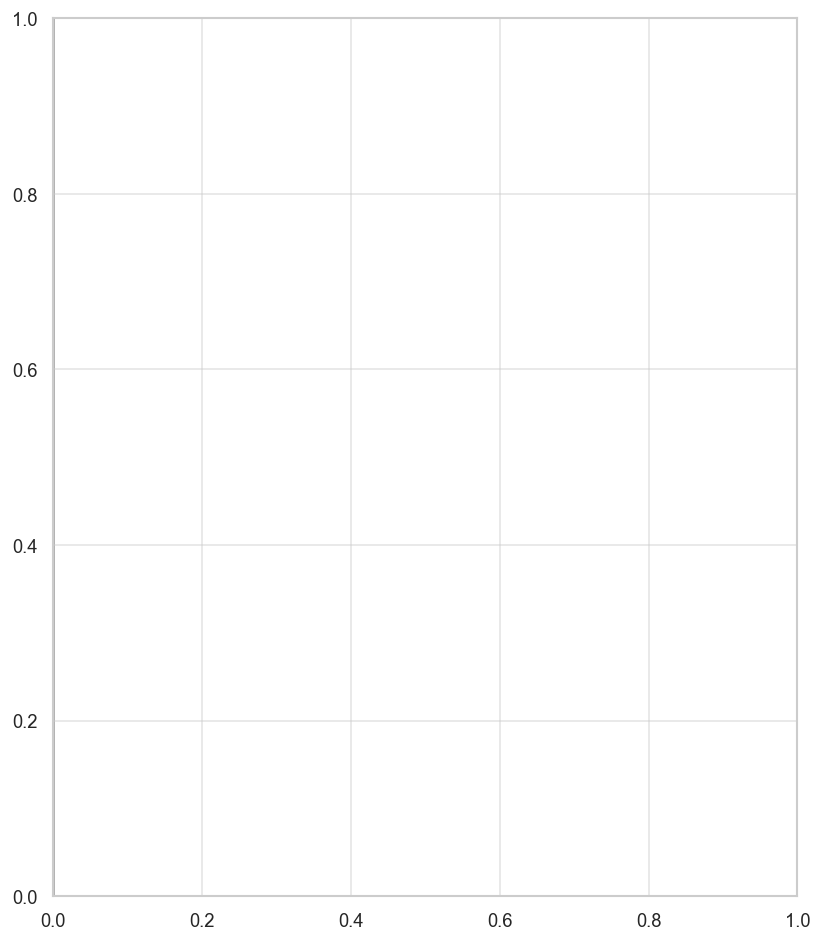

In [18]:
RUN_RESEARCH = True
if RUN_RESEARCH:
    research_summary = run_random50(**research_config)
    display(pd.Series(research_summary, name="research_summary"))

## 9. Locate latest output

In [19]:
outputs = sorted((PROJECT / "outputs").glob(f"{FEATURE_FAMILY}_*"), key=lambda p: p.stat().st_mtime, reverse=True)
latest_out = outputs[0] if outputs else None
print("latest_out:", latest_out)
if outputs:
    display(pd.DataFrame([{"name": p.name, "mtime": pd.to_datetime(p.stat().st_mtime, unit="s"), "files": sum(1 for _ in p.rglob("*"))} for p in outputs[:10]]))

latest_out: D:\SCJ999\srateries\RandomForest\RF_MLFlow\outputs\random50_initial_features_tod_dow_baseline_1788883216


,name,mtime,files
0,random50_initial_features_tod_dow_baseline_178...,2026-09-08 16:28:09.287308216,706
1,random50_initial_features_tod_dow_baseline_178...,2026-09-05 16:55:42.205264330,812
2,random50_initial_features_tod_dow_baseline_178...,2026-09-05 16:07:34.741744995,810
3,random50_initial_features_tod_dow_baseline_178...,2026-09-05 15:23:00.068488359,3
4,random50_initial_features_tod_dow_baseline_178...,2026-09-05 15:05:33.458456278,243


## 10. Summary audit

In [20]:
RESULT_DIR = latest_out

if RESULT_DIR is not None:
    summary_path = RESULT_DIR / "random50_summary.csv"
    checkpoint_path = RESULT_DIR / "random50_summary_checkpoint.csv"
    summary_json_path = RESULT_DIR / "summary.json"
    print({"summary_csv": summary_path.exists(), "checkpoint": checkpoint_path.exists(), "summary_json": summary_json_path.exists()})
    if summary_json_path.exists():
        display(json.loads(summary_json_path.read_text(encoding="utf-8")))
    if summary_path.exists():
        summary = pd.read_csv(summary_path)
    elif checkpoint_path.exists():
        summary = pd.read_csv(checkpoint_path)
    else:
        summary = pd.DataFrame()
    display(summary.head(20))
else:
    summary = pd.DataFrame()

{'summary_csv': True, 'checkpoint': True, 'summary_json': True}


{'run_id': 1788883216,
 'feature_family': 'random50_initial_features_tod_dow_baseline',
 'n_models': 50,
 'max_train_rows': 120000,
 'best_model': {'model_name': 'rf_random_45',
  'n_features': 53,
  'groups': 'ma_overlay|trendline_overlay|ema|mtf_m5|session_signal|channel_overlay|mtf_h4',
  'threshold': 0.55,
  'valid_auc': 0.4934097921630882,
  'valid_brier': 0.2515059850414278,
  'test_auc': 0.5096239279404012,
  'test_brier': 0.2503384728026793,
  'test_total_resolved': 5544,
  'test_total_wr': 64.1775,
  'test_min_year_deals': 531,
  'objective_score': 61.86074191069128,
  'top10_features': 'h4_volatility_12|h4_ema_dist_55|h4_volatility_6|h4_volatility_3|h4_ema_slope_21|h4_ret|h4_ret_sum_6|h4_ret_sum_3|h4_range|h4_ema_slope_8',
  'model_path': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\models\\random50_initial_features_tod_dow_baseline_1788883216_rf_random_45_bundle.joblib'},
 'out_dir': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\outputs\\random50_initial_features_tod_

,model_name,n_features,groups,threshold,valid_auc,valid_brier,test_auc,test_brier,test_total_resolved,test_total_wr,test_min_year_deals,objective_score,top10_features,model_path
0,rf_random_45,53,ma_overlay|trendline_overlay|ema|mtf_m5|sessio...,0.55,0.493410,0.251506,0.509624,0.250338,5544,64.1775,531,61.860742,h4_volatility_12|h4_ema_dist_55|h4_volatility_...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
1,rf_random_38,52,mtf_h4|candle|rolling|ema|bb_overlay|mtf_m5,0.58,0.512503,0.250721,0.499846,0.251175,1522,65.4402,153,58.275413,h4_ema_slope_55|h4_ret|h4_volatility_3|h4_ema_...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
2,rf_random_30,25,trendline_overlay|mtf_h4,0.57,0.500804,0.252656,0.514578,0.249955,5427,66.1139,365,55.568836,h4_volatility_12|h4_ema_slope_55|h4_rsi_14|h4_...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
3,rf_random_22,34,rolling|mtf_m15|channel_overlay|lags,0.53,0.497348,0.250479,0.499341,0.250417,3675,58.8844,238,55.308474,range_std_200|range_mean_200|m15_ema_dist_55|t...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
4,rf_random_46,27,channel_overlay|bb_overlay|session_signal,0.54,0.514829,0.249945,0.506559,0.250232,8624,55.9369,2031,53.644072,bb200_mid_ov_velocity3_lag1|tod_cos|bb200_uppe...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
5,rf_random_47,49,rolling|ma_overlay|trendline_overlay|ema|rsi|m...,0.57,0.509337,0.250776,0.511002,0.250411,5594,57.9371,1003,52.356803,h4_ret|h4_ret_sum_6|h4_range|h4_ret_sum_12|tod...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
6,rf_random_08,49,channel_overlay|ma_overlay|ema|bb_overlay|sess...,0.56,0.496881,0.251705,0.513995,0.250098,9047,58.9477,2069,51.305452,h4_rsi_14|h4_ema_dist_21|h4_range|dow_cos|dow_...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
7,rf_random_41,48,ma_overlay|rolling|ema|lags|bb_overlay|mtf_h4,0.54,0.510063,0.250274,0.516185,0.249717,9092,59.1509,1584,51.013414,h4_rsi_14|h4_volatility_6|h4_ema_slope_55|h4_v...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
8,rf_random_34,60,mtf_h4|mtf_m5|rsi|ema|trendline_overlay|sessio...,0.56,0.499969,0.252177,0.516753,0.250232,10076,58.9917,1739,50.369091,h4_volatility_12|h4_rsi_14|h4_volatility_6|h4_...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...
9,rf_random_26,25,session_signal|mtf_h4,0.57,0.490835,0.253189,0.511741,0.250351,10094,57.5094,1968,49.008776,h4_volatility_12|h4_rsi_14|h4_ema_slope_55|h4_...,D:\SCJ999\srateries\RandomForest\RF_MLFlow\mod...


In [21]:
if len(summary):
    cols_to_show = [c for c in ["model_name", "n_features", "groups", "threshold", "valid_auc", "test_auc", "test_total_wr", "test_total_resolved", "test_min_year_deals", "objective_score"] if c in summary.columns]
    display(summary.sort_values("objective_score", ascending=False)[cols_to_show].head(20))
    display(summary.sort_values("valid_auc", ascending=False)[cols_to_show].head(20))

,model_name,n_features,groups,threshold,valid_auc,test_auc,test_total_wr,test_total_resolved,test_min_year_deals,objective_score
0,rf_random_45,53,ma_overlay|trendline_overlay|ema|mtf_m5|sessio...,0.55,0.493410,0.509624,64.1775,5544,531,61.860742
1,rf_random_38,52,mtf_h4|candle|rolling|ema|bb_overlay|mtf_m5,0.58,0.512503,0.499846,65.4402,1522,153,58.275413
2,rf_random_30,25,trendline_overlay|mtf_h4,0.57,0.500804,0.514578,66.1139,5427,365,55.568836
3,rf_random_22,34,rolling|mtf_m15|channel_overlay|lags,0.53,0.497348,0.499341,58.8844,3675,238,55.308474
4,rf_random_46,27,channel_overlay|bb_overlay|session_signal,0.54,0.514829,0.506559,55.9369,8624,2031,53.644072
5,rf_random_47,49,rolling|ma_overlay|trendline_overlay|ema|rsi|m...,0.57,0.509337,0.511002,57.9371,5594,1003,52.356803
6,rf_random_08,49,channel_overlay|ma_overlay|ema|bb_overlay|sess...,0.56,0.496881,0.513995,58.9477,9047,2069,51.305452
7,rf_random_41,48,ma_overlay|rolling|ema|lags|bb_overlay|mtf_h4,0.54,0.510063,0.516185,59.1509,9092,1584,51.013414
8,rf_random_34,60,mtf_h4|mtf_m5|rsi|ema|trendline_overlay|sessio...,0.56,0.499969,0.516753,58.9917,10076,1739,50.369091
9,rf_random_26,25,session_signal|mtf_h4,0.57,0.490835,0.511741,57.5094,10094,1968,49.008776


,model_name,n_features,groups,threshold,valid_auc,test_auc,test_total_wr,test_total_resolved,test_min_year_deals,objective_score
16,rf_random_24,26,bb_overlay|session_signal|mtf_m15,0.53,0.525033,0.506746,54.3394,4632,1070,46.271790
43,rf_random_16,34,rolling|rsi|trendline_overlay|mtf_m5,0.55,0.524432,0.501380,47.6355,3468,63,19.153203
22,rf_random_05,17,mtf_m15|rsi|channel_overlay,0.53,0.522490,0.509160,54.8832,10014,1601,44.378172
44,rf_random_20,22,candle|session_signal|ma_overlay,0.56,0.521985,0.506416,53.3333,45,1,9.095939
10,rf_random_04,38,ema|trendline_overlay|candle|session_signal|ch...,0.54,0.520693,0.498755,52.1890,11809,2776,48.454746
37,rf_random_01,23,candle|rsi|lags,0.54,0.520157,0.498855,53.4249,4730,515,35.236182
33,rf_random_29,32,rsi|lags|rolling|candle,0.53,0.518087,0.495915,51.8066,4096,665,38.562438
14,rf_random_14,42,session_signal|ma_overlay|bb_overlay|ema|candle,0.54,0.516821,0.502469,56.4727,2835,402,47.193715
18,rf_random_31,22,mtf_h1|lags|rolling,0.56,0.516820,0.502313,52.9266,4049,2,45.344623
11,rf_random_25,54,mtf_h4|trendline_overlay|mtf_m5|candle|ma_over...,0.54,0.516572,0.513663,54.0493,10792,1713,48.341393


## 11. Model artifact audit

In [22]:
if RESULT_DIR is not None:
    explain_dir = RESULT_DIR / "explainability"
    model_dirs = sorted([p for p in explain_dir.glob("lgbm_random_*") if p.is_dir()]) if explain_dir.exists() else []
    audit_rows = []
    for d in model_dirs:
        files = list(d.glob("*"))
        audit_rows.append(
            {
                "model": d.name,
                "files": len(files),
                "importance_csv": any(f.name.endswith("_lgbm_importance.csv") for f in files),
                "threshold_valid": any("threshold_valid" in f.name for f in files),
                "threshold_test": any("threshold_test" in f.name for f in files),
                "shap": any("shap" in f.name for f in files),
            }
        )
    artifact_audit = pd.DataFrame(audit_rows)
    display(artifact_audit.head(50))

""


## 12. Inspect best model

{'best_model': 'rf_random_45', 'best_dir': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow\\outputs\\random50_initial_features_tod_dow_baseline_1788883216\\explainability\\rf_random_45'}


model_name                                                  rf_random_45
n_features                                                            53
groups                 ma_overlay|trendline_overlay|ema|mtf_m5|sessio...
threshold                                                           0.55
valid_auc                                                        0.49341
valid_brier                                                     0.251506
test_auc                                                        0.509624
test_brier                                                      0.250338
test_total_resolved                                                 5544
test_total_wr                                                    64.1775
test_min_year_deals                                                  531
objective_score                                                61.860742
top10_features         h4_volatility_12|h4_ema_dist_55|h4_volatility_...
model_path             D:\SCJ999\srateries\RandomFo

rf_random_45_threshold_valid.png


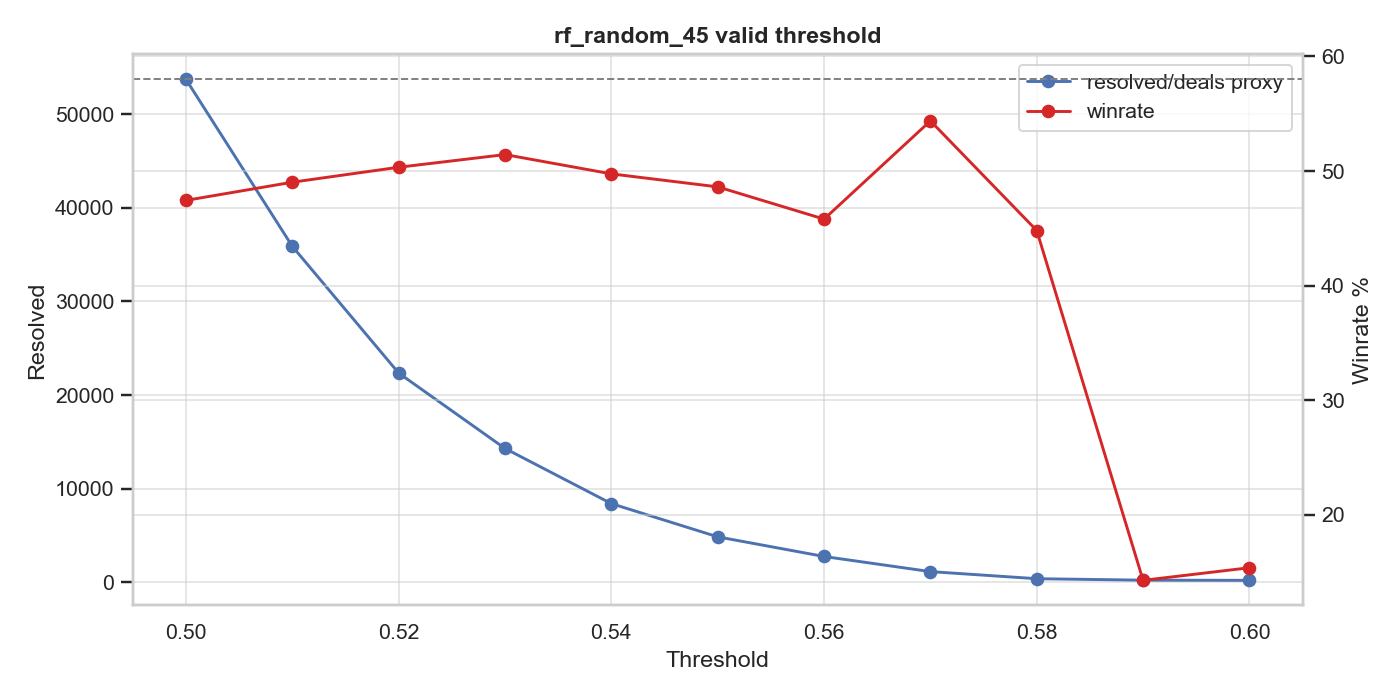

rf_random_45_threshold_test.png


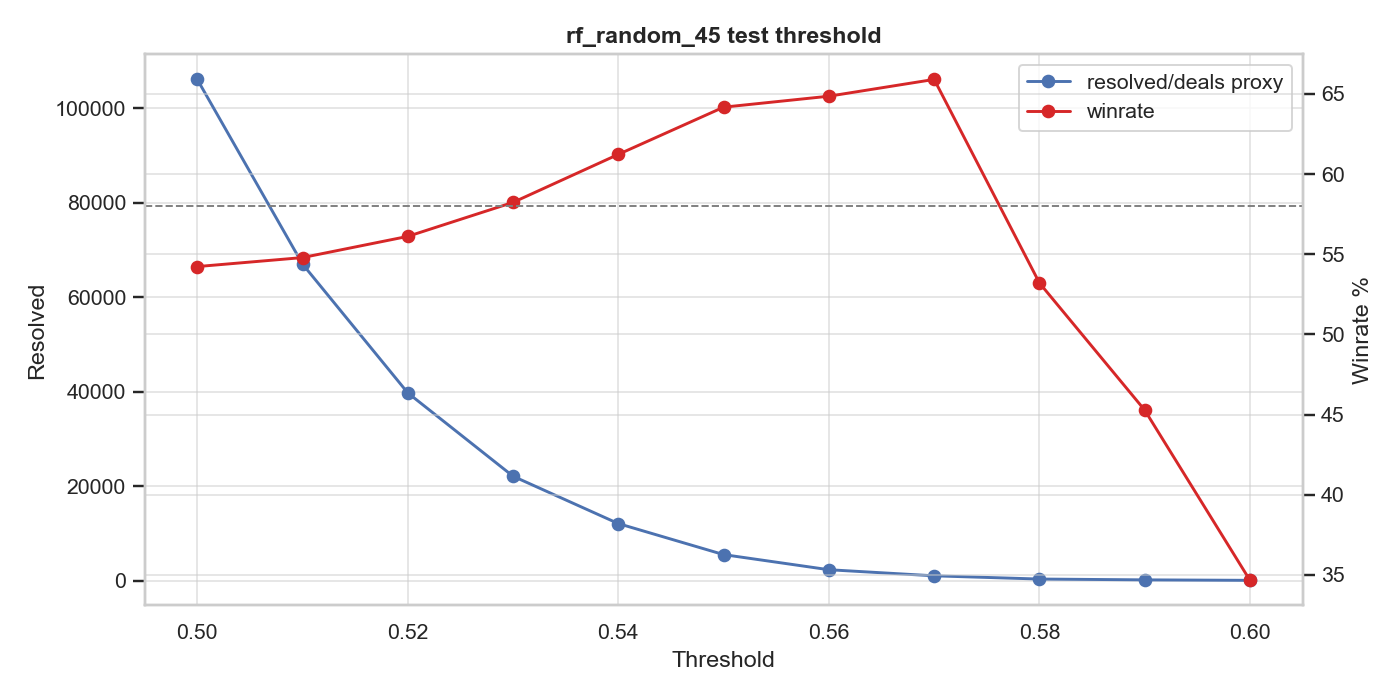

In [23]:
if len(summary):
    best = summary.sort_values("objective_score", ascending=False).iloc[0]
    best_name = best["model_name"]
    best_dir = RESULT_DIR / "explainability" / best_name
    print({"best_model": best_name, "best_dir": str(best_dir)})
    display(best)

    imp_files = list(best_dir.glob("*_lgbm_importance.csv"))
    if imp_files:
        imp = pd.read_csv(imp_files[0])
        display(imp.head(50))

    for png in [best_dir / f"{best_name}_lgbm_importance_top25.png", best_dir / f"{best_name}_threshold_valid.png", best_dir / f"{best_name}_threshold_test.png"]:
        if png.exists():
            print(png.name)
            display(Image(filename=str(png)))

## 13. Feature usage audit across random specs/results

In [24]:
if RESULT_DIR is not None:
    specs_path = RESULT_DIR / "random_model_specs.json"
    if specs_path.exists():
        specs_done = json.loads(specs_path.read_text(encoding="utf-8"))
        feature_counts = {}
        for spec in specs_done:
            for f in spec.get("features", []):
                feature_counts[f] = feature_counts.get(f, 0) + 1
        usage = pd.DataFrame([{"feature": k, "n_models": v} for k, v in feature_counts.items()]).sort_values("n_models", ascending=False)
        usage["is_overlay"] = usage.feature.str.contains("_ov_", regex=False)
        display(usage.head(80))
        display(usage.groupby("is_overlay").agg(features=("feature", "count"), total_usages=("n_models", "sum")))

,feature,n_models,is_overlay
0,tod_sin,50,False
1,tod_cos,50,False
2,dow_sin,50,False
3,dow_cos,50,False
16,close_diff_lag_5,38,False
...,...,...,...
143,m5_ema_dist_8,6,False
190,h4_ema_dist_8,6,False
203,m5_ret,6,False
254,ema_dist_13,6,False


,features,total_usages
is_overlay,,
False,179,1430
True,304,360


## 14. MLflow audit

In [25]:
mlflow = _mlflow()
print("mlflow available:", mlflow is not None)
if mlflow is not None:
    exp = mlflow.get_experiment_by_name(CFG.experiment_name)
    print({"experiment_id": exp.experiment_id if exp else None, "name": CFG.experiment_name})
    # Mở UI ngoài notebook nếu cần:
    # mlflow ui --backend-store-uri sqlite:///D:/SCJ999/mlflow.db --host 127.0.0.1 --port 5000

mlflow available: True
{'experiment_id': '1', 'name': 'RF_MLFlow_XAUUSD_M1_Buy_WinLose'}


## 15. Quality gates

Dùng checklist này trước khi kết luận model tốt:

- `valid_auc` không quá thấp.
- `test_auc` không sụp về 0.5.
- `test_total_wr` tốt hơn baseline.
- `test_total_resolved` đủ lớn.
- `test_min_year_deals` không quá thấp.
- Top features có logic thị trường.
- Không phụ thuộc quá mức vào time/session nếu không có lý do rõ.
- Chạy lại seed khác không đổi quá mạnh.